# Real-data experiment 2: California commuting-displacement tensors

This notebook reproduces the county-scale affine-invariant SPD example.
Each California residence county is represented by a two-by-two second
moment of within-state commuting displacements. A compact public
derivative contains the 58 tensors and the metadata needed for the
analysis; `DATA_SOURCES.md` documents how it was constructed from the
official ACS flow workbook and Census Gazetteer.

`PAPER_SCALE=True` reproduces the manuscript's 999 global and 499 local
permutations; set it to `False` for 499 global permutations.

In [1]:
from pathlib import Path
import json
import sys

ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "autocorr.py").is_file() and (path / "data").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Start Jupyter from public/ or public/notebooks/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import autocorr as ac

ac.set_notebook_style()
paper = json.loads((ROOT / "data" / "paper_scale_summary.json").read_text())
PAPER_SCALE = True
print(f"Public root located. PAPER_SCALE={PAPER_SCALE}")

Public root located. PAPER_SCALE=True


In [2]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Ellipse, Patch

SEED = 20260719
global_permutations = 999 if PAPER_SCALE else 499
local_permutations = 499
archive = ac.load_california()
tensors = archive["tensors"]
metadata = pd.DataFrame({
    "GEOID": archive["geoid"], "county": archive["county"],
    "lon": archive["lon"], "lat": archive["lat"],
    "x": archive["x"], "y": archive["y"],
    "within_ca_workers": archive["within_ca_workers"],
    "destinations": archive["destinations"],
})
coordinates = metadata[["x", "y"]].to_numpy(float)
W = ac.sym_knn(coordinates, k=4)
mean_tensor, logarithms, distance_squared, dispersion = ac.spd_components(tensors)
global_result = ac.global_randomization(
    logarithms, distance_squared, W, V_mu=dispersion,
    permutations=global_permutations, seed=SEED + 1,
)
local = ac.local_diagnostics(
    logarithms, distance_squared, W,
    permutations=local_permutations, seed=SEED + 101,
)
local = ac.classification_columns(pd.concat([metadata, local], axis=1))

summary = {**global_result.__dict__, **ac.summarize_local(local)}
display(pd.DataFrame([summary]).round(4))
print(f"Common SPD ridge: {float(archive['epsilon_m2']):,.3f} square metres")
print("Affine-invariant mean tensor:")
display(pd.DataFrame(mean_tensor).round(3))

,I,C_F,C_P,C_T,kappa,CP_over_CT,L,center_residual_ratio,p_I_upper,p_CP_lower,permutations,local_moran_aligned,local_moran_anti_aligned,local_geary_homogeneous,local_geary_transition_outlier,local_overlap
0,0.3676,0.6511,0.6356,0.6294,1.0245,1.0098,0.008,0.0,0.001,0.001,999,12,0,13,0,9


Common SPD ridge: 248,340.273 square metres
Affine-invariant mean tensor:


,0,1
0,9.492570e+08,-4.025701e+08
1,-4.025701e+08,1.189362e+09


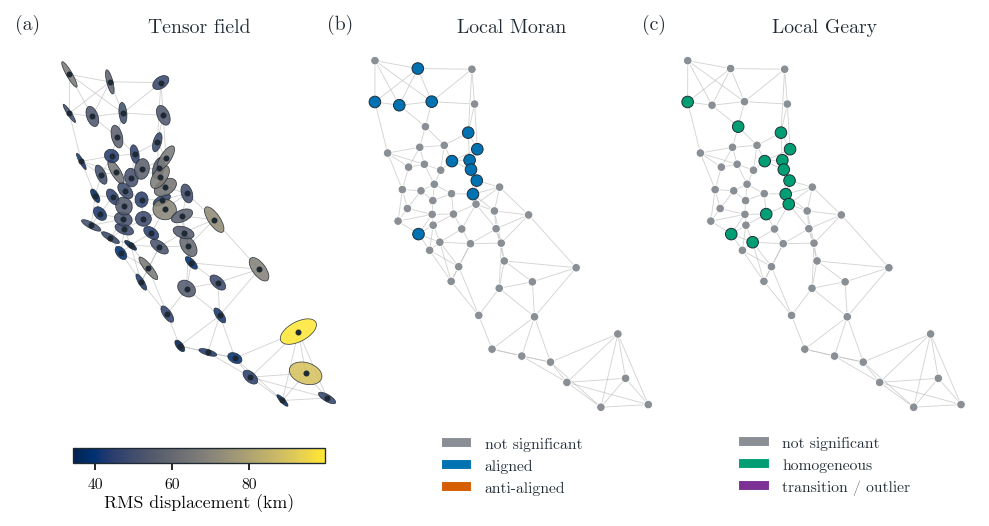

In [3]:
rms_km = np.sqrt(np.trace(tensors, axis1=1, axis2=2)) / 1000.0
norm = Normalize(vmin=float(rms_km.min()), vmax=float(rms_km.max()))
cmap = plt.get_cmap("cividis")

figure = plt.figure(figsize=(ac.TEXT_WIDTH_IN, 3.6), constrained_layout=False)
grid = figure.add_gridspec(
    2, 3, left=0.04, right=0.99, bottom=0.06, top=0.91,
    height_ratios=[1.0, 0.20], wspace=0.04, hspace=0.02,
)
axes = [figure.add_subplot(grid[0, index]) for index in range(3)]
guides = [figure.add_subplot(grid[1, index]) for index in range(3)]
for guide in guides:
    guide.axis("off")
for ax in axes:
    ac.draw_graph(ax, coordinates, W)

glyph_scale = 0.66
for (x, y), tensor, value in zip(coordinates, tensors, rms_km):
    eigenvalues, eigenvectors = np.linalg.eigh((tensor + tensor.T) / 2)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    major = eigenvectors[:, 0]
    angle = np.degrees(np.arctan2(major[1], major[0]))
    axes[0].add_patch(Ellipse(
        (x, y), width=2 * np.sqrt(eigenvalues[0]) * glyph_scale,
        height=2 * np.sqrt(eigenvalues[1]) * glyph_scale,
        angle=angle, facecolor=cmap(norm(value)), edgecolor=ac.INK,
        linewidth=0.36, alpha=0.88, zorder=3,
    ))
axes[0].scatter(coordinates[:, 0], coordinates[:, 1], s=3.5, c=ac.INK, zorder=4)
colorbar_ax = guides[0].inset_axes([0.08, 0.54, 0.84, 0.20])
colorbar = figure.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=colorbar_ax,
                          orientation="horizontal")
colorbar.set_label("RMS displacement (km)", labelpad=1.0)
axes[0].set_title("Tensor field")

for ax, column, palette, title, guide in [
    (axes[1], "moran_class", ac.MORAN_COLORS, "Local Moran", guides[1]),
    (axes[2], "geary_class", ac.GEARY_COLORS, "Local Geary", guides[2]),
]:
    for label, color in palette.items():
        subset = local[local[column] == label]
        significant = subset["I_significant" if column == "moran_class" else "G_significant"].to_numpy(bool)
        ax.scatter(subset["x"], subset["y"], s=np.where(significant, 31, 17),
                   c=color, edgecolors=np.where(significant, ac.INK, "white"),
                   linewidths=0.45, zorder=3)
    ax.set_title(title)
    guide.legend(handles=[Patch(facecolor=color, edgecolor="white", label=label)
                          for label, color in palette.items()], loc="center")

for letter, ax in zip("abc", axes):
    ac.map_axis(ax)
    ac.panel_label(ax, letter)
plt.show()

**Figure 1.** Panel (a) displays the commuting-displacement tensors;
ellipse axes encode principal direction and anisotropy, while color
records root-mean-square displacement. Gray links show the symmetric
four-nearest-neighbor graph. Panels (b) and (c) show the FDR-adjusted
local Moran and pairwise Geary classes.

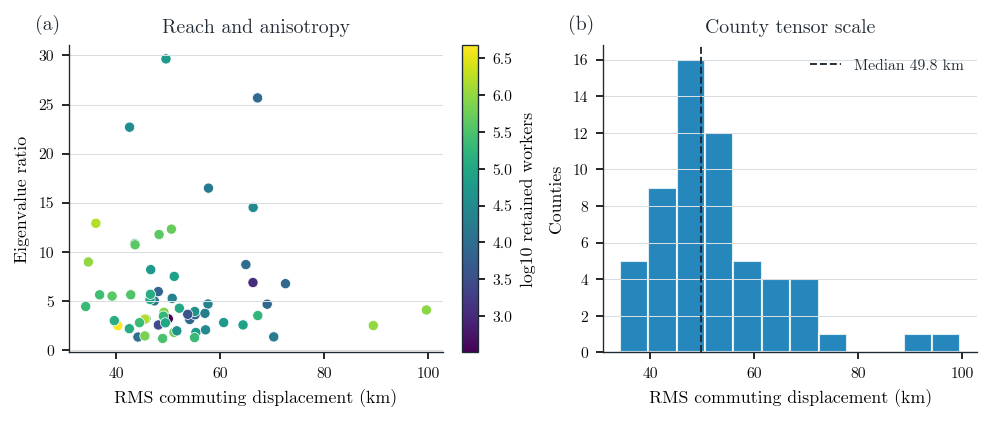

In [4]:
eigenvalues = np.linalg.eigvalsh(tensors)
anisotropy = eigenvalues[:, 1] / eigenvalues[:, 0]
fig, axes = plt.subplots(1, 2, figsize=(ac.TEXT_WIDTH_IN, 2.7), constrained_layout=True)
points = axes[0].scatter(rms_km, anisotropy, c=np.log10(metadata["within_ca_workers"]),
                         cmap="viridis", s=24, edgecolors="white", linewidths=0.35)
axes[0].set(xlabel="RMS commuting displacement (km)", ylabel="Eigenvalue ratio",
            title="Reach and anisotropy")
colorbar = fig.colorbar(points, ax=axes[0])
colorbar.set_label("log10 retained workers")

axes[1].hist(rms_km, bins=12, color=ac.BLUE, alpha=0.85, edgecolor="white")
axes[1].axvline(np.median(rms_km), color=ac.INK, linestyle="--", linewidth=0.9,
                label=f"Median {np.median(rms_km):.1f} km")
axes[1].set(xlabel="RMS commuting displacement (km)", ylabel="Counties",
            title="County tensor scale")
axes[1].legend()
for letter, ax in zip("ab", axes):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color=ac.GRID, linewidth=0.5)
    ac.panel_label(ax, letter)
plt.show()

**Figure 2.** Additional tensor diagnostics. Panel (a) relates overall
displacement scale to anisotropy and retained worker volume. Panel (b)
shows the distribution of tensor scales across the 58 counties.

In [5]:
paper_result = paper["california_commuting_tensors"]
comparison = pd.DataFrame([
    {"run": "Fresh notebook", **summary},
    {"run": "Archived manuscript", **paper_result},
])
display(comparison[[
    "run", "I", "C_F", "C_P", "C_T", "p_I_upper", "p_CP_lower",
    "local_moran_aligned", "local_geary_homogeneous",
]].round(4))

strongest = local.sort_values(["q_local_I", "GEOID"]).head(10)[
    ["county", "local_I", "q_local_I", "I_direction"]
]
display(strongest.round(4))

,run,I,C_F,C_P,C_T,p_I_upper,p_CP_lower,local_moran_aligned,local_geary_homogeneous
0,Fresh notebook,0.3676,0.6511,0.6356,0.6294,0.001,0.001,12,13
1,Archived manuscript,0.3676,0.6511,0.6356,0.6294,0.001,0.001,12,13


,county,local_I,q_local_I,I_direction
11,Humboldt County,6.4545,0.0193,aligned
28,Nevada County,5.6093,0.0193,aligned
30,Placer County,7.0458,0.0193,aligned
31,Plumas County,4.4955,0.0193,aligned
52,Trinity County,1.6646,0.0193,aligned
57,Yuba County,3.5549,0.0193,aligned
2,Amador County,4.8682,0.0258,aligned
45,Sierra County,6.5309,0.0258,aligned
46,Siskiyou County,3.8915,0.0258,aligned
40,San Mateo County,4.0680,0.0316,aligned
